In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy import stats, optimize
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

plt.rcParams['grid.alpha'] = 0.3

UNDERLYING = 'VELVETFRUIT_EXTRACT'
STRIKES    = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
OPT_SYMS   = [f'VEV_{k}' for k in STRIKES]
ALL_PRODS  = [UNDERLYING] + OPT_SYMS
POS_LIMIT  = 100

In [2]:
# ── Load all price data ───────────────────────────────────────────────────────
price_dfs = []
for day in [0, 1, 2]:
    df = pd.read_csv(f'round3/prices_round_3_day_{day}.csv', sep=';')
    df['global_ts'] = day * 1_000_000 + df['timestamp']
    price_dfs.append(df)
all_prices = pd.concat(price_dfs, ignore_index=True)

# Numeric coerce
vol_cols = [f'{side}_volume_{i}' for side in ['bid','ask'] for i in [1,2,3]]
price_col = [f'{side}_price_{i}' for side in ['bid','ask'] for i in [1,2,3]]
for col in vol_cols + price_col:
    all_prices[col] = pd.to_numeric(all_prices[col], errors='coerce')

# Separate underlying and options
und = all_prices[all_prices['product'] == UNDERLYING].copy().reset_index(drop=True)
und['spread'] = und['ask_price_1'] - und['bid_price_1']
und['mid'] = und['mid_price']

opts = {sym: all_prices[all_prices['product'] == sym].copy().reset_index(drop=True)
        for sym in OPT_SYMS}
for sym in OPT_SYMS:
    opts[sym]['spread'] = opts[sym]['ask_price_1'] - opts[sym]['bid_price_1']
    opts[sym]['mid'] = opts[sym]['mid_price']

print(f'Underlying ticks: {len(und)}')
print(f'Options ticks per symbol: {len(opts["VEV_5000"])}')
print(und[['day','timestamp','bid_price_1','ask_price_1','mid']].head(5))

Underlying ticks: 30000
Options ticks per symbol: 30000
   day  timestamp  bid_price_1  ask_price_1     mid
0    0          0         5247         5253  5250.0
1    0        100         5248         5253  5250.5
2    0        200         5248         5253  5250.5
3    0        300         5248         5253  5250.5
4    0        400         5248         5253  5250.5


In [3]:
# ── Load trade data ───────────────────────────────────────────────────────────
trade_dfs = []
for day in [0, 1, 2]:
    df = pd.read_csv(f'round3/trades_round_3_day_{day}.csv', sep=';')
    df['day'] = day
    df['global_ts'] = day * 1_000_000 + df['timestamp']
    trade_dfs.append(df)
trades_all = pd.concat(trade_dfs, ignore_index=True)
print(f'Total trade events: {len(trades_all)}')
print(f'Symbols traded: {sorted(trades_all["symbol"].unique())}')

Total trade events: 4048
Symbols traded: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


In [4]:
# ── Volume-weighted mid, best-bid, and best-ask series indexed by global_ts ───
def make_opt_mid(df_opt):
    bid_num = ask_num = bid_den = ask_den = 0
    for lvl in [1, 2, 3]:
        bp = pd.to_numeric(df_opt[f'bid_price_{lvl}'],  errors='coerce')
        bv = pd.to_numeric(df_opt[f'bid_volume_{lvl}'], errors='coerce')
        ap = pd.to_numeric(df_opt[f'ask_price_{lvl}'],  errors='coerce')
        av = pd.to_numeric(df_opt[f'ask_volume_{lvl}'], errors='coerce')
        bid_num = bid_num + (bp * bv).fillna(0)
        bid_den = bid_den + bv.fillna(0)
        ask_num = ask_num + (ap * av).fillna(0)
        ask_den = ask_den + av.fillna(0)
    vw_bid = bid_num / bid_den.replace(0, np.nan)
    vw_ask = ask_num / ask_den.replace(0, np.nan)
    return (vw_bid + vw_ask) / 2

opts_mid = {}
opts_bid = {}   # L1 best bid price
opts_ask = {}   # L1 best ask price
for sym in OPT_SYMS:
    idx = opts[sym]['global_ts'].values
    opts_mid[sym] = pd.Series(make_opt_mid(opts[sym]).values, index=idx)
    opts_bid[sym] = pd.Series(
        pd.to_numeric(opts[sym]['bid_price_1'], errors='coerce').values, index=idx)
    opts_ask[sym] = pd.Series(
        pd.to_numeric(opts[sym]['ask_price_1'], errors='coerce').values, index=idx)

print("opts_mid / opts_bid / opts_ask computed for:", list(opts_mid.keys()))

opts_mid / opts_bid / opts_ask computed for: ['VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


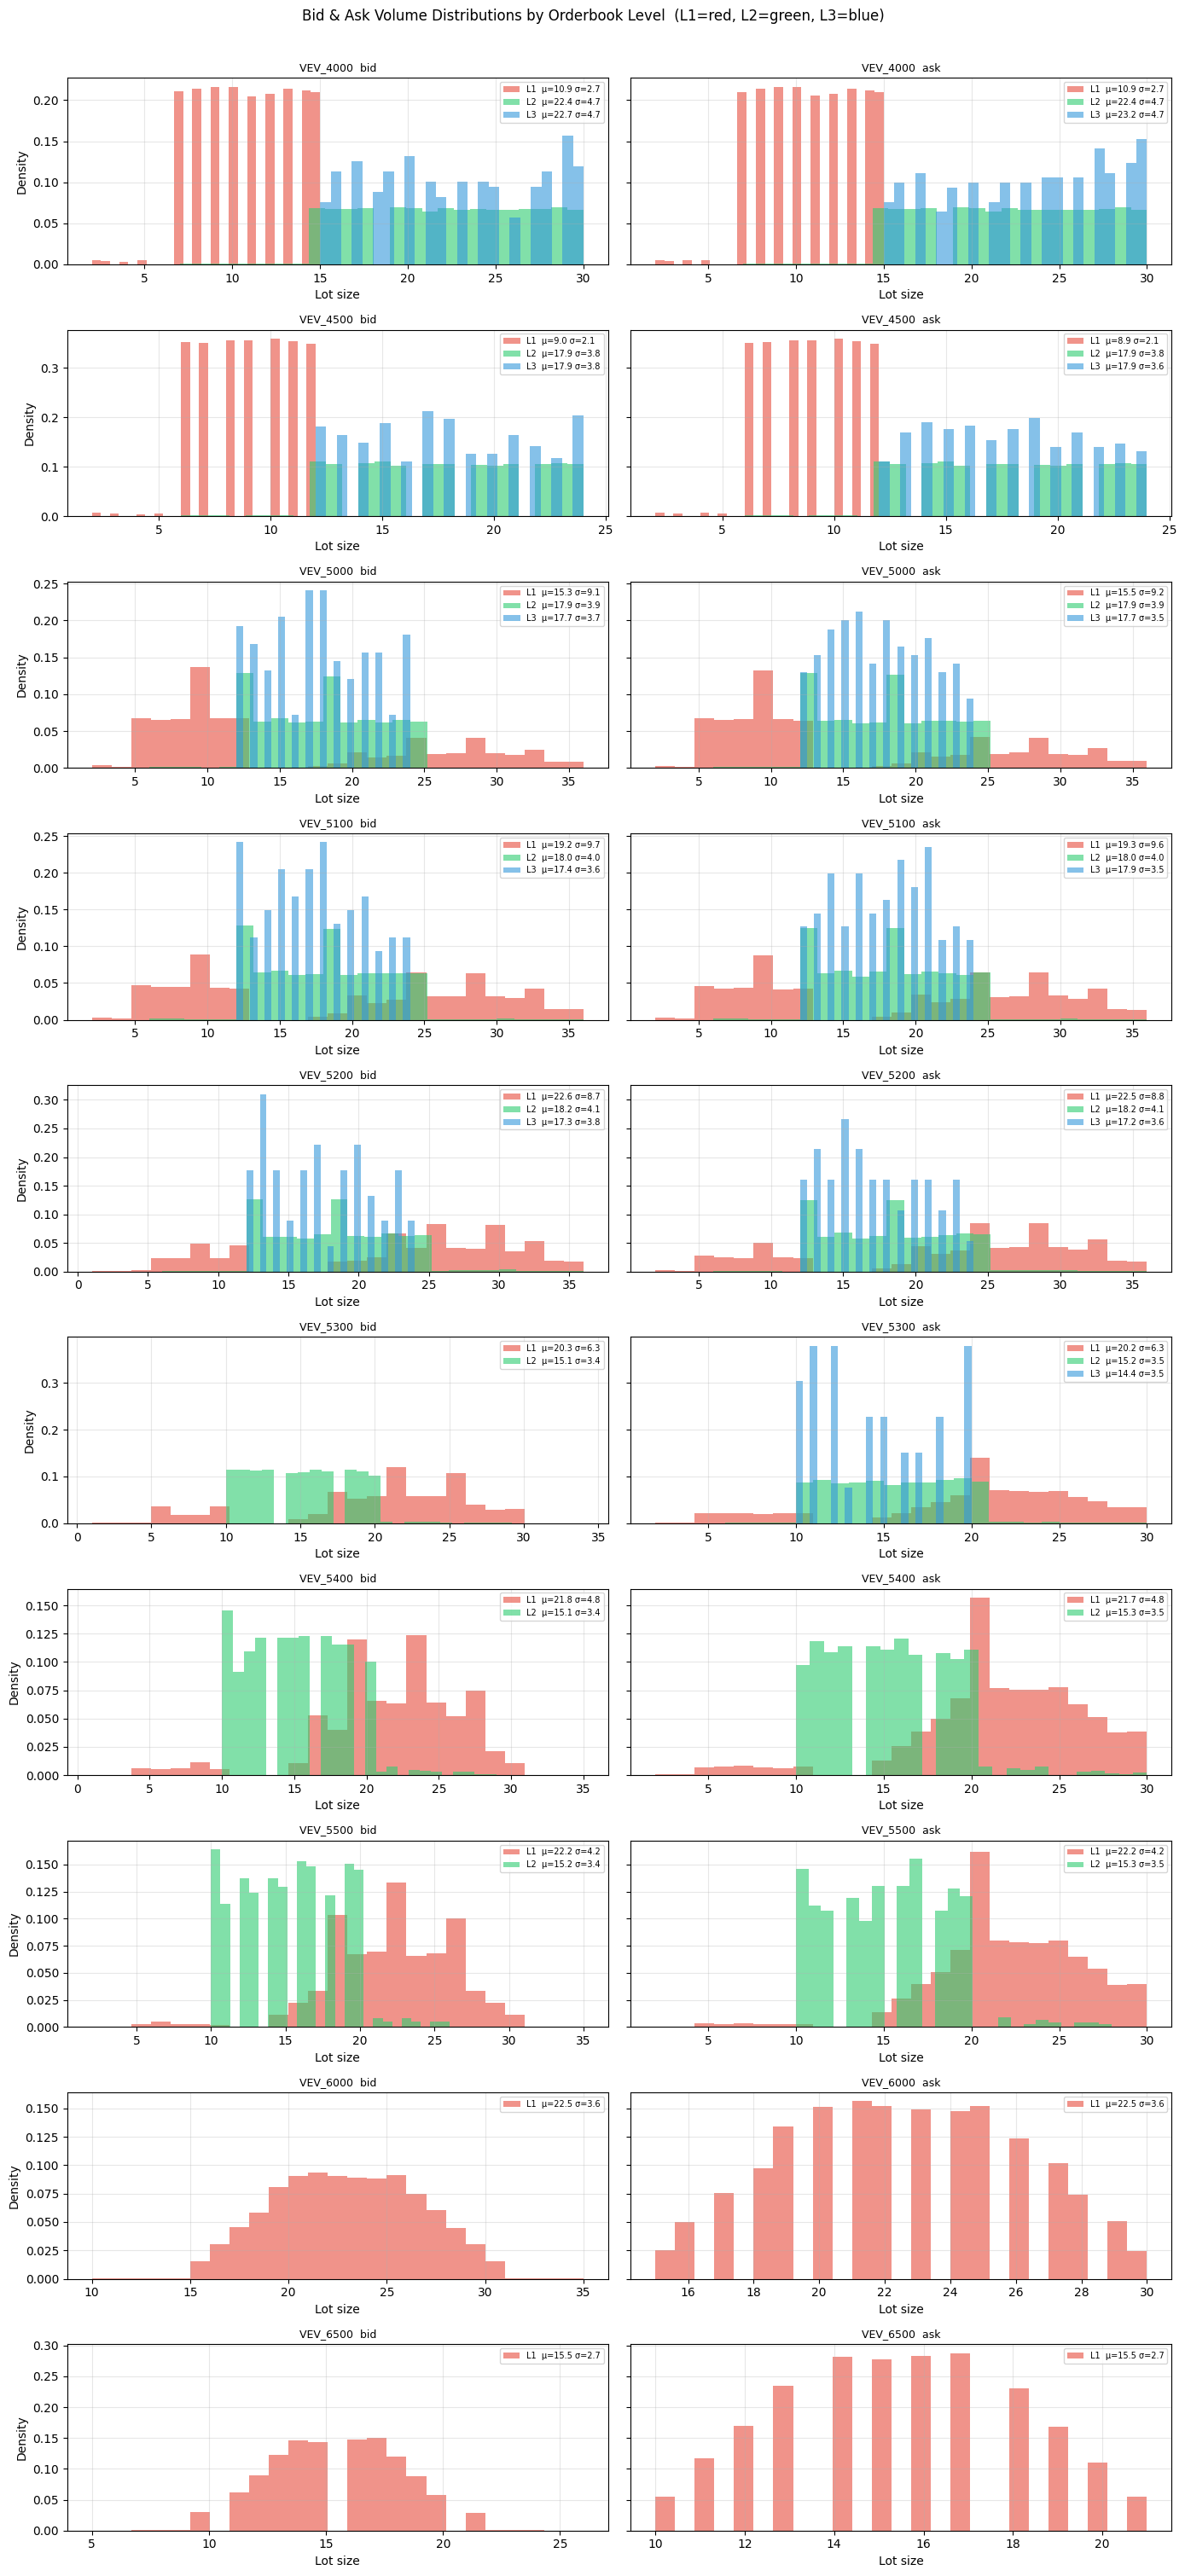


Strike    bid_L1 (μ±σ)     bid_L2 (μ±σ)     bid_L3 (μ±σ)     ask_L1 (μ±σ)     ask_L2 (μ±σ)     ask_L3 (μ±σ)   
VEV_4000  10.9±2.7         22.4±4.7         22.7±4.7         10.9±2.7         22.4±4.7         23.2±4.7       
VEV_4500  9.0±2.1          17.9±3.8         17.9±3.8         8.9±2.1          17.9±3.8         17.9±3.6       
VEV_5000  15.3±9.1         17.9±3.9         17.7±3.7         15.5±9.2         17.9±3.9         17.7±3.5       
VEV_5100  19.2±9.7         18.0±4.0         17.4±3.6         19.3±9.6         18.0±4.0         17.9±3.5       
VEV_5200  22.6±8.7         18.2±4.1         17.3±3.8         22.5±8.8         18.2±4.1         17.2±3.6       
VEV_5300  20.3±6.3         15.1±3.4         —                20.2±6.3         15.2±3.5         14.4±3.5       
VEV_5400  21.8±4.8         15.1±3.4         —                21.7±4.8         15.3±3.5         —              
VEV_5500  22.2±4.2         15.2±3.4         —                22.2±4.2         15.3±3.5         —              


In [5]:
# ── Orderbook size distributions by level ────────────────────────────────────
# Is level 1 noisy small participants, with a large reliable MM deeper in book?

level_colors = {1: '#e74c3c', 2: '#2ecc71', 3: '#3498db'}

fig, axes = plt.subplots(len(OPT_SYMS), 2, figsize=(14, 3 * len(OPT_SYMS)), sharey='row')

for row_i, (sym, K) in enumerate(zip(OPT_SYMS, STRIKES)):
    df_opt = opts[sym]
    for col_i, side in enumerate(['bid', 'ask']):
        ax = axes[row_i, col_i]
        for lvl in [1, 2, 3]:
            v = pd.to_numeric(df_opt[f'{side}_volume_{lvl}'], errors='coerce').dropna()
            if len(v) == 0:
                continue
            ax.hist(v, bins=25, alpha=0.6, color=level_colors[lvl],
                    label=f'L{lvl}  μ={v.mean():.1f} σ={v.std():.1f}',
                    density=True)
        ax.set_title(f'VEV_{K}  {side}', fontsize=9)
        ax.set_xlabel('Lot size')
        if col_i == 0:
            ax.set_ylabel('Density')
        ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Bid & Ask Volume Distributions by Orderbook Level  '
             '(L1=red, L2=green, L3=blue)', fontsize=12, y=1.005)
plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Strike':<8}", end='')
for side in ['bid', 'ask']:
    for lvl in [1, 2, 3]:
        print(f"  {side}_L{lvl} (μ±σ)".ljust(17), end='')
print()

for sym, K in zip(OPT_SYMS, STRIKES):
    df_opt = opts[sym]
    print(f"VEV_{K:<4}", end='')
    for side in ['bid', 'ask']:
        for lvl in [1, 2, 3]:
            v = pd.to_numeric(df_opt[f'{side}_volume_{lvl}'], errors='coerce').dropna()
            txt = f"{v.mean():.1f}±{v.std():.1f}" if len(v) else "—"
            print(f"  {txt:<15}", end='')
    print()

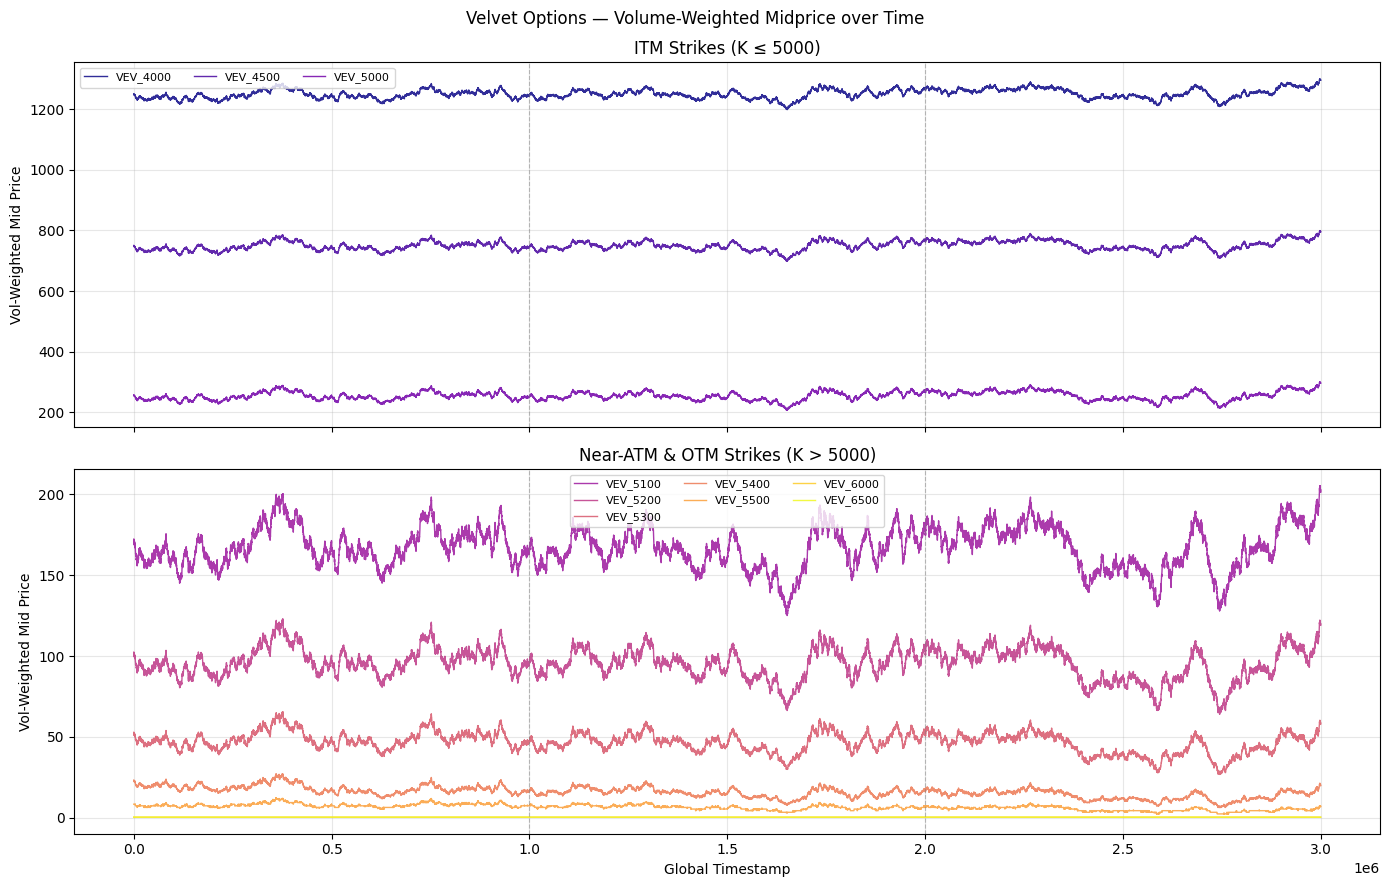

In [6]:
# ── Option price over time (volume-weighted mid) ──────────────────────────────
colors = cm.plasma(np.linspace(0, 1, len(OPT_SYMS)))

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Top panel: ITM / deep-ITM strikes (high absolute price)
itm_syms  = [(sym, K, c) for sym, K, c in zip(OPT_SYMS, STRIKES, colors) if K <= 5000]
# Bottom panel: near-ATM and OTM (lower absolute price, more detail visible)
otm_syms  = [(sym, K, c) for sym, K, c in zip(OPT_SYMS, STRIKES, colors) if K > 5000]

for ax, group, title in zip(axes,
                             [itm_syms, otm_syms],
                             ['ITM Strikes (K ≤ 5000)', 'Near-ATM & OTM Strikes (K > 5000)']):
    for sym, K, c in group:
        s = opts_mid[sym]
        ax.plot(s.index, s.values, label=f'VEV_{K}', color=c, lw=1.0, alpha=0.85)
    for d in [1, 2]:
        ax.axvline(d * 1_000_000, color='grey', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('Vol-Weighted Mid Price')
    ax.set_title(title)
    ax.legend(ncol=3, fontsize=8)

axes[-1].set_xlabel('Global Timestamp')
fig.suptitle('Velvet Options — Volume-Weighted Midprice over Time', fontsize=12)
plt.tight_layout()
plt.show()

# SSVI Vol Curve Calibration

Fit **SSVI** (Surface SVI, Gatheral & Jacquier) to the Velvet options smile at sampled timestamps.

SSVI total implied variance at log-moneyness `k = log(K/S)`:

`w(k) = (θ/2) · [1 + ρφk + √((φk + ρ)² + 1 − ρ²)]`

Parameters:
- **θ (theta)**: ATM total implied variance = σ²_ATM × T. Declines as expiry approaches.
- **ρ (rho)**: Skew — rotates the curve. ρ<0 = downside skew (put wing expensive), ρ>0 = call wing expensive.
- **φ (phi)**: Convexity — controls how wide the wings are. Higher φ → tighter smile.

Why SSVI over SABR for this market:
- SSVI fits in **log-moneyness space** `k = log(K/S)` — the natural domain for smile fitting.
- θ is directly interpretable (σ²·T); its time decay is the vol term structure signal.
- With a flat smile and narrow strike range (k ∈ [−0.05, +0.05]), SABR's α/ρ/ν are poorly identified. SSVI correctly returns ρ≈0, φ≈small, and a stable θ.
- The SSVI parameters ρ and φ are mean-reverting across various timeframes — the exploitable signal.

**Time convention:** T in days (TICKS_PER_DAY = 10,000). σ in vol/√day.  
`tte_at(global_ts) = (8,000,000 − global_ts) / 100` → TTE in ticks; divide by TICKS_PER_DAY for days.

In [7]:
from scipy.stats import norm
from scipy.optimize import brentq, minimize

EXPIRY_TS     = 8_000_000
TS_PER_TICK   = 100
TICKS_PER_DAY = 10_000
MIN_TV        = 1.0

# Only these strikes have meaningful IV (4000/4500 TV=0; 6000/6500 bid=0/ask=1 TV=0.5)
SSVI_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

def tte_at(global_ts):
    """TTE in ticks."""
    return max((EXPIRY_TS - global_ts) / TS_PER_TICK, 1e-6)

# ── Black-Scholes (calls, r=0) — T in ticks, σ in vol/√tick ──────────────────
def bs_call(S, K, T, sigma):
    if T <= 1e-8 or sigma <= 1e-8:
        return max(S - K, 0.0)
    d1 = (np.log(S / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def implied_vol(call_price, S, K, T):
    """BS call inversion. T in ticks → σ in vol/√tick. NaN if TV < MIN_TV."""
    if T <= 1e-8:
        return np.nan
    intrinsic = max(S - K, 0.0)
    if call_price - intrinsic < MIN_TV:
        return np.nan
    try:
        return brentq(lambda sig: bs_call(S, K, T, sig) - call_price, 1e-9, 1.0, xtol=1e-12)
    except Exception:
        return np.nan

# ── SSVI (Gatheral & Jacquier) ────────────────────────────────────────────────
# w(k) = (θ/2)[1 + ρφk + √((φk+ρ)² + 1−ρ²)]
# k = log(K/S) : log-moneyness
# θ : ATM total variance (σ²·T)  — declines with TTE
# ρ : skew  [-1, 1]
# φ : convexity (wing width)  > 0

def ssvi_total_variance(k, theta, rho, phi):
    """SSVI total implied variance w(k). All inputs scalar."""
    return (theta / 2) * (1.0 + rho * phi * k + np.sqrt((phi * k + rho)**2 + 1.0 - rho**2))

def ssvi_vol(k, theta, rho, phi, T_days):
    """SSVI implied vol (vol/√day) at log-moneyness k."""
    w = ssvi_total_variance(k, theta, rho, phi)
    return np.sqrt(max(w, 1e-12) / T_days)

def ssvi_vol_vec(ks, theta, rho, phi, T_days):
    return np.array([ssvi_vol(k, theta, rho, phi, T_days) for k in ks])

# ── SSVI calibration ──────────────────────────────────────────────────────────
def fit_ssvi(F, strikes, market_ivs_day, T_days):
    """
    Fit SSVI in log-moneyness space.
    Inputs: market_ivs_day in vol/√day, T_days in days.
    Returns (theta, rho, phi).
      theta ≈ σ²_ATM × T_days
      rho   ≈ 0 for symmetric smile
      phi   ≈ convexity (controls wing width)
    """
    mask = np.isfinite(market_ivs_day) & (market_ivs_day > 0)
    if mask.sum() < 2:
        return (np.nan, np.nan, np.nan)
    Ks  = np.array(strikes)[mask]
    ivs = np.array(market_ivs_day)[mask]
    ks  = np.log(Ks / F)               # log-moneyness
    w_mkt = ivs**2 * T_days            # market total variance

    def objective(params):
        theta, rho, phi = params
        if theta <= 0 or abs(rho) >= 1 or phi <= 0:
            return 1e8
        try:
            w_model = np.array([ssvi_total_variance(k, theta, rho, phi) for k in ks])
            if np.any(w_model <= 0):
                return 1e8
            return np.sum((w_model - w_mkt)**2)
        except Exception:
            return 1e8

    atm_idx    = np.argmin(np.abs(ks))
    theta_init = ivs[atm_idx]**2 * T_days   # σ²_ATM × T

    res = minimize(objective, [theta_init, 0.0, 1.0], method='L-BFGS-B',
                   bounds=[(1e-8, 4.0), (-0.999, 0.999), (1e-6, 20.0)],
                   options={'maxiter': 500, 'ftol': 1e-14})
    return tuple(res.x) if (res.success or res.fun < 1e-10) else (np.nan, np.nan, np.nan)

print("SSVI helpers loaded.")
print(f"  BS   : T in ticks, σ in vol/√tick")
print(f"  SSVI : T in days, σ in vol/√day, k = log(K/S)")
print(f"TTE at round 0 start: {tte_at(0):,.0f} ticks = {tte_at(0)/TICKS_PER_DAY:.0f} days")
print(f"TTE at round 3 start: {tte_at(3_000_000):,.0f} ticks = {tte_at(3_000_000)/TICKS_PER_DAY:.0f} days  ← current")

SSVI helpers loaded.
  BS   : T in ticks, σ in vol/√tick
  SSVI : T in days, σ in vol/√day, k = log(K/S)
TTE at round 0 start: 80,000 ticks = 8 days
TTE at round 3 start: 50,000 ticks = 5 days  ← current


In [8]:
# ── Sample timestamps & compute IV smile (mid, bid, ask) ─────────────────────
SAMPLE_STEP = 200

sample_ts   = und['global_ts'].values[::SAMPLE_STEP]
und_indexed = und.set_index('global_ts')['mid']

rows = []
for gts in sample_ts:
    T = tte_at(gts)
    pos = und_indexed.index.searchsorted(gts, side='right') - 1
    if pos < 0:
        continue
    F = und_indexed.iloc[pos]
    row = {'global_ts': gts, 'T': T, 'F': F}
    for sym, K in zip(OPT_SYMS, STRIKES):
        pos_o = opts_mid[sym].index.searchsorted(gts, side='right') - 1
        if pos_o >= 0:
            mid_p = opts_mid[sym].iloc[pos_o]
            bid_p = opts_bid[sym].iloc[pos_o]
            ask_p = opts_ask[sym].iloc[pos_o]
        else:
            mid_p = bid_p = ask_p = np.nan
        row[f'iv_{K}']     = implied_vol(mid_p, F, K, T)
        row[f'bid_iv_{K}'] = implied_vol(bid_p, F, K, T)
        row[f'ask_iv_{K}'] = implied_vol(ask_p, F, K, T)
    rows.append(row)

df_iv = pd.DataFrame(rows).set_index('global_ts')

nan_counts = df_iv[[f'iv_{K}' for K in STRIKES]].isna().sum().rename('NaN count')
print(f"IV snapshots: {len(df_iv)}")
print(nan_counts)
print()
print("NaN explanation:")
print("  VEV_4000/4500 : deep ITM — MM quotes at intrinsic with zero time premium → TV=0 < MIN_TV=1")
print("  VEV_6000/6500 : deep OTM — bid=0, ask=1, mid=0.5 → TV=0.5 < MIN_TV=1")
print("  VEV_5000–5500 : all valid — these are the SABR fitting strikes")

IV snapshots: 150
iv_4000    147
iv_4500    147
iv_5000      0
iv_5100      0
iv_5200      0
iv_5300      0
iv_5400      0
iv_5500      0
iv_6000    150
iv_6500    150
Name: NaN count, dtype: int64

NaN explanation:
  VEV_4000/4500 : deep ITM — MM quotes at intrinsic with zero time premium → TV=0 < MIN_TV=1
  VEV_6000/6500 : deep OTM — bid=0, ask=1, mid=0.5 → TV=0.5 < MIN_TV=1
  VEV_5000–5500 : all valid — these are the SABR fitting strikes


In [9]:
# ── Fit SSVI at each sample timestamp ────────────────────────────────────────
# Fit in log-moneyness space with σ in vol/√day.
# Converts BS IVs (vol/√tick) → vol/√day before fitting.
ssvi_rows = []
for gts, row in df_iv.iterrows():
    T_ticks = row['T']
    T_days  = T_ticks / TICKS_PER_DAY
    F       = row['F']
    ivs_day = np.array([row[f'iv_{K}'] for K in SSVI_STRIKES]) * np.sqrt(TICKS_PER_DAY)
    theta, rho, phi = fit_ssvi(F, SSVI_STRIKES, ivs_day, T_days)
    ssvi_rows.append({'global_ts': gts, 'T': T_ticks, 'T_days': T_days, 'F': F,
                      'theta': theta, 'rho': rho, 'phi': phi})

df_ssvi = pd.DataFrame(ssvi_rows).set_index('global_ts')
print(f"SSVI calibrations: {len(df_ssvi)}")
print()
print("Parameter meanings:")
print("  theta = σ²_ATM × T  (ATM total variance, declines as expiry nears)")
print("  rho   = skew         (≈0 symmetric smile, negative = downside skew)")
print("  phi   = convexity    (wing width; higher = more curvature)")
print()
print(df_ssvi[['theta','rho','phi']].describe().round(6))

if df_ssvi['theta'].notna().any():
    theta_m = df_ssvi['theta'].median()
    T_m     = df_ssvi['T_days'].median()
    print(f"\nMedian θ={theta_m:.6f}  →  σ_ATM(day) = √(θ/T) = {np.sqrt(theta_m/T_m):.5f} vol/√day")
    print(f"  = {np.sqrt(theta_m/T_m)/np.sqrt(TICKS_PER_DAY):.7f} vol/√tick")

SSVI calibrations: 150

Parameter meanings:
  theta = σ²_ATM × T  (ATM total variance, declines as expiry nears)
  rho   = skew         (≈0 symmetric smile, negative = downside skew)
  phi   = convexity    (wing width; higher = more curvature)

            theta    rho    phi
count  150.000000  150.0  150.0
mean     0.001037    0.0    1.0
std      0.000131    0.0    0.0
min      0.000803   -0.0    1.0
25%      0.000920   -0.0    1.0
50%      0.001027    0.0    1.0
75%      0.001148    0.0    1.0
max      0.001270    0.0    1.0

Median θ=0.001027  →  σ_ATM(day) = √(θ/T) = 0.01256 vol/√day
  = 0.0001256 vol/√tick


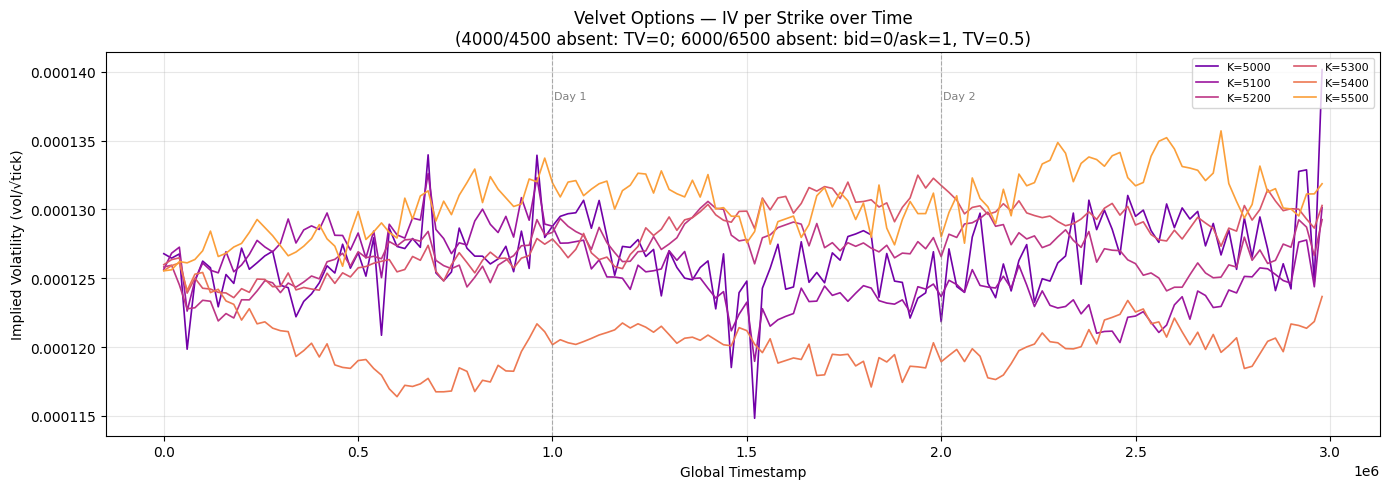

In [10]:
# ── Plot 1: IV per strike over time ──────────────────────────────────────────
# VEV_4000/4500 absent: MM prices at intrinsic, zero time value → NaN from implied_vol.
# VEV_6000/6500 absent: bid=0/ask=1, TV=0.5 < MIN_TV=1 → NaN.
# Only VEV_5000–5500 have meaningful IV (shown below).
iv_cols = [f'iv_{K}' for K in STRIKES]
colors  = cm.plasma(np.linspace(0, 1, len(STRIKES)))

fig, ax = plt.subplots(figsize=(14, 5))
for col, K, c in zip(iv_cols, STRIKES, colors):
    if K in [4000, 4500, 6000, 6500]:
        continue
    
    series = df_iv[col].dropna()
    if len(series) == 0:
        continue
    ax.plot(series.index, series.values, label=f'K={K}', color=c, lw=1.2)

for d in [1, 2]:
    ax.axvline(d * 1_000_000, color='grey', lw=0.8, ls='--', alpha=0.6)
    ax.text(d * 1_000_000 + 5000, ax.get_ylim()[1] * 0.98,
            f'Day {d}', fontsize=8, color='grey', va='top')

ax.set_xlabel('Global Timestamp')
ax.set_ylabel('Implied Volatility (vol/√tick)')
ax.set_title('Velvet Options — IV per Strike over Time\n'
             '(4000/4500 absent: TV=0; 6000/6500 absent: bid=0/ask=1, TV=0.5)')
ax.legend(ncol=2, fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

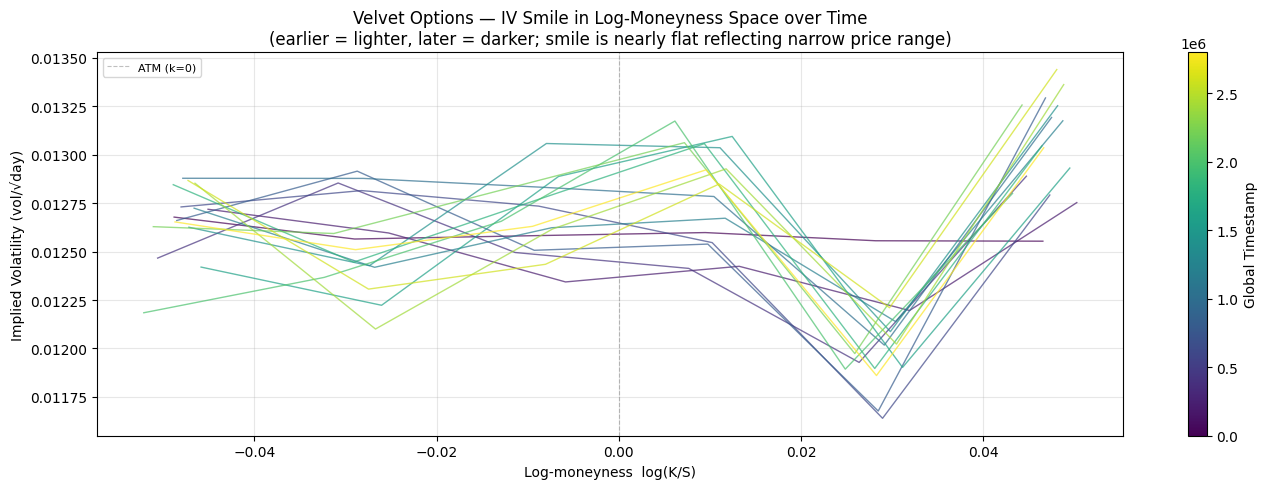

In [11]:
# ── Plot 2: IV smile snapshots in log-moneyness space ────────────────────────
# X-axis: log(K/S), consistent with SSVI model domain.
snap_indices = df_iv.index[::10]
smile_colors = cm.viridis(np.linspace(0, 1, len(snap_indices)))

fig, ax = plt.subplots(figsize=(14, 5))
for gts, c in zip(snap_indices, smile_colors):
    row = df_iv.loc[gts]
    F   = row['F']
    ivs_day  = [row[f'iv_{K}'] * np.sqrt(TICKS_PER_DAY) for K in SSVI_STRIKES]
    ks_mkt   = [np.log(K / F) for K in SSVI_STRIKES]
    valid    = [(k, iv) for k, iv in zip(ks_mkt, ivs_day) if np.isfinite(iv)]
    if len(valid) >= 2:
        ks_v, ivs_v = zip(*valid)
        ax.plot(ks_v, ivs_v, color=c, lw=1.0, alpha=0.7)

ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.5, label='ATM (k=0)')
sm = plt.cm.ScalarMappable(cmap='viridis',
     norm=plt.Normalize(snap_indices.min(), snap_indices.max()))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Global Timestamp')
ax.set_xlabel('Log-moneyness  log(K/S)')
ax.set_ylabel('Implied Volatility (vol/√day)')
ax.set_title('Velvet Options — IV Smile in Log-Moneyness Space over Time\n'
             '(earlier = lighter, later = darker; smile is nearly flat reflecting narrow price range)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

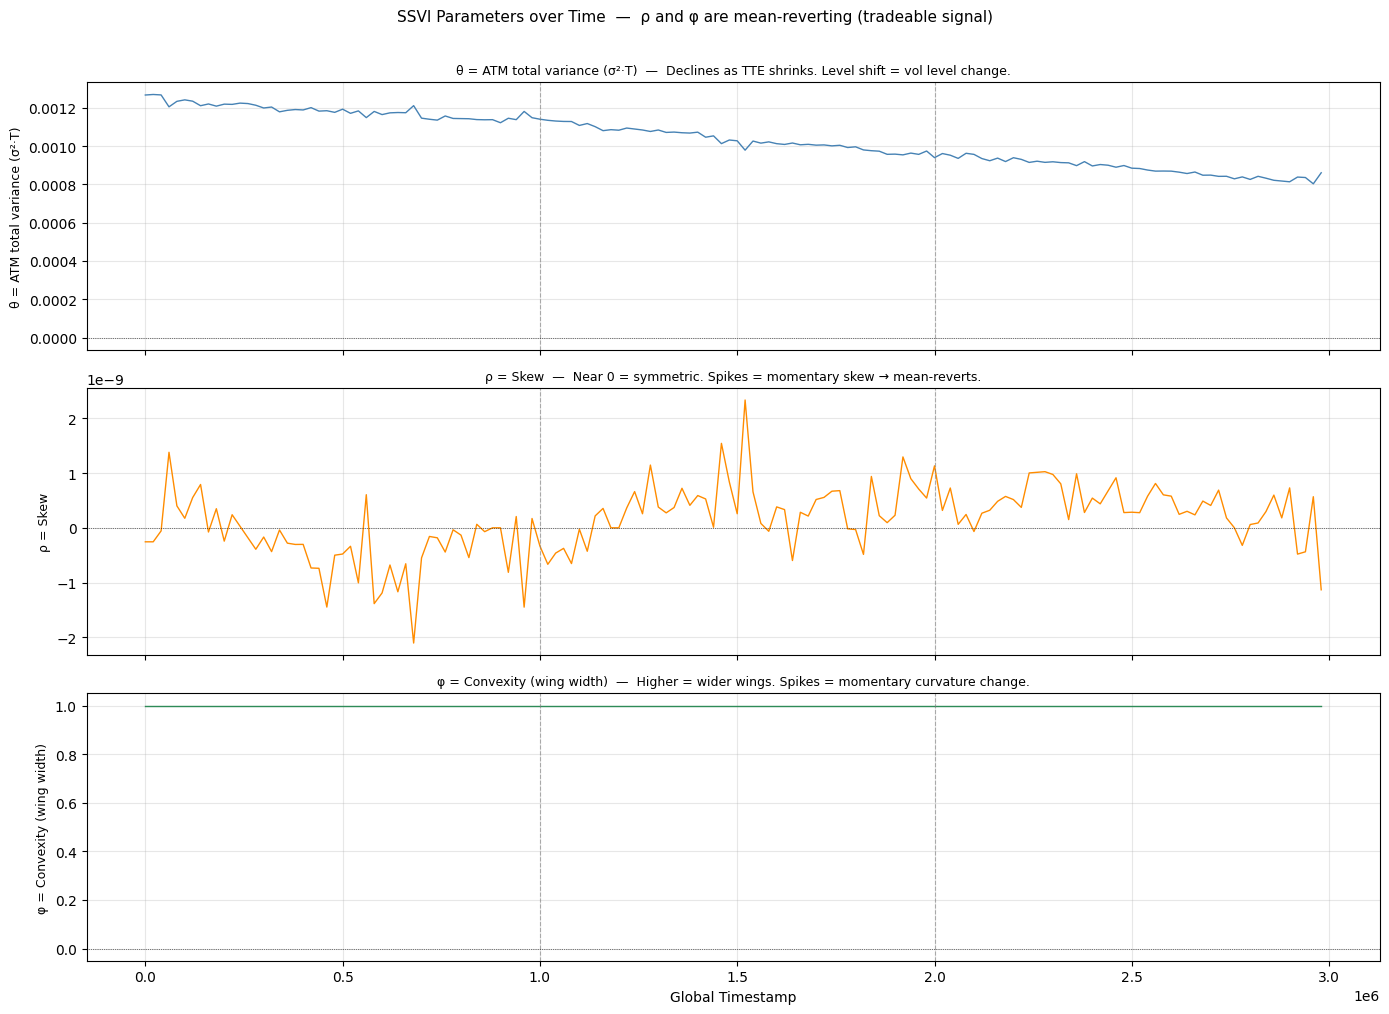

Parameter std / mean (coefficient of variation):
  theta : mean=0.00104  std=0.00013  CV=0.127
  rho   : mean=0.00000  std=0.00000  CV=4.366
  phi   : mean=1.00000  std=0.00000  CV=0.000


In [12]:
# ── Plot 3: SSVI parameters over time ────────────────────────────────────────
# θ should decline monotonically (it's σ²·T, and T is shrinking).
# ρ and φ are mean-reverting — spikes are the tradeable signal.
param_info = [
    ('theta', 'θ = ATM total variance (σ²·T)', 'steelblue',
     'Declines as TTE shrinks. Level shift = vol level change.'),
    ('rho',   'ρ = Skew',                       'darkorange',
     'Near 0 = symmetric. Spikes = momentary skew → mean-reverts.'),
    ('phi',   'φ = Convexity (wing width)',      'seagreen',
     'Higher = wider wings. Spikes = momentary curvature change.'),
]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, (col, label, color, note) in zip(axes, param_info):
    series = df_ssvi[col].dropna()
    ax.plot(series.index, series.values, color=color, lw=1.0)
    ax.set_ylabel(label, fontsize=9)
    ax.set_title(f'{label}  —  {note}', fontsize=9)
    for d in [1, 2]:
        ax.axvline(d * 1_000_000, color='grey', lw=0.8, ls='--', alpha=0.6,
                   label=f'Day {d}' if d == 1 else None)
    ax.axhline(0, color='black', lw=0.5, ls=':')

axes[-1].set_xlabel('Global Timestamp')
fig.suptitle('SSVI Parameters over Time  —  ρ and φ are mean-reverting (tradeable signal)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

# Print summary of parameter stability
print("Parameter std / mean (coefficient of variation):")
for col in ['theta', 'rho', 'phi']:
    s = df_ssvi[col].dropna()
    cv = s.std() / abs(s.mean()) if s.mean() != 0 else np.nan
    print(f"  {col:6s}: mean={s.mean():.5f}  std={s.std():.5f}  CV={cv:.3f}")

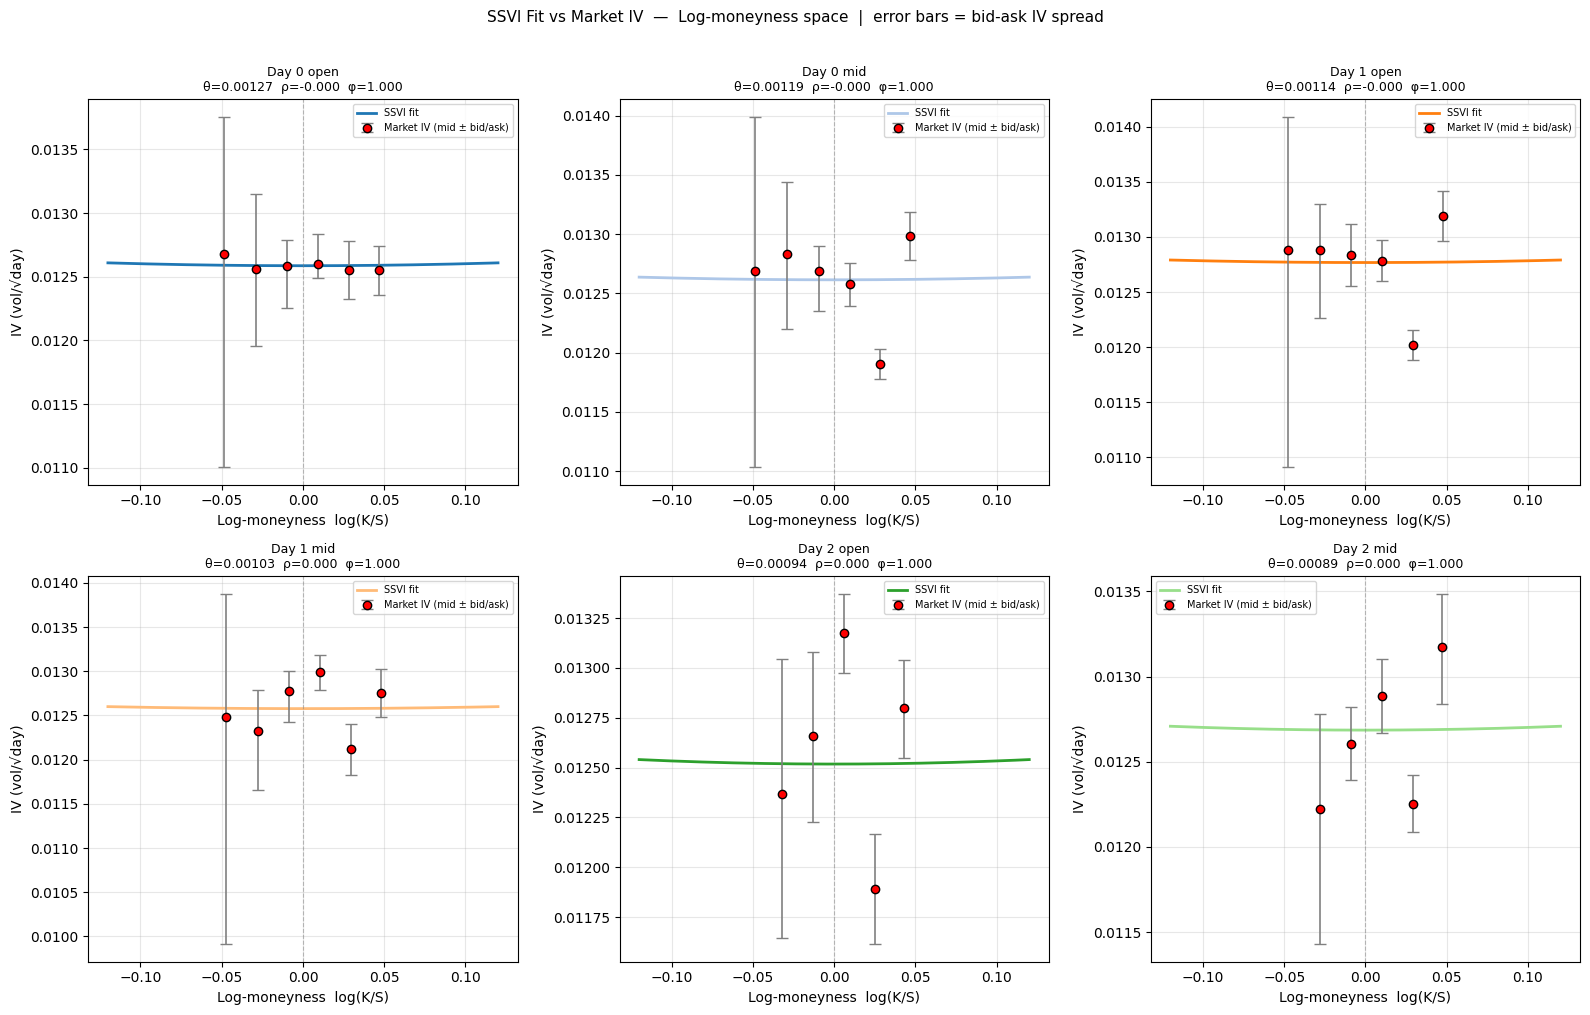

In [13]:
# ── Plot 4: SSVI fit vs market IVs in log-moneyness space ────────────────────
# Matches the professional style from the PDF (Gatheral / Deribit / Optiver style):
#   X-axis : log-moneyness k = log(K/S)  [0 = ATM]
#   Y-axis : implied volatility (vol/√day)
#   Line   : fitted SSVI curve
#   Dots   : mid IV (red)
#   Bars   : bid-ask IV spread (gray error bars)
#
# If SSVI line > ask IV → option cheap → BUY at ask (take)
# If SSVI line < bid IV → option rich  → SELL at bid (take)
# If SSVI line inside bar → market make into position
snapshot_targets = [0, 500_000, 1_000_000, 1_500_000, 2_000_000, 2_500_000]
snapshot_labels  = ['Day 0 open', 'Day 0 mid',
                    'Day 1 open', 'Day 1 mid',
                    'Day 2 open', 'Day 2 mid']
colors6 = ['#1f77b4','#aec7e8','#ff7f0e','#ffbb78','#2ca02c','#98df8a']

k_fine = np.linspace(-0.12, 0.12, 300)   # log-moneyness grid for SSVI curve

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, target_ts, label, color in zip(axes, snapshot_targets, snapshot_labels, colors6):
    idx   = min(df_ssvi.index.searchsorted(target_ts, side='left'), len(df_ssvi) - 1)
    gts   = df_ssvi.index[idx]
    row_s = df_ssvi.loc[gts]
    row_iv= df_iv.loc[gts]

    F, T_days       = row_s['F'], row_s['T_days']
    theta, rho, phi = row_s['theta'], row_s['rho'], row_s['phi']

    Ks   = np.array(SSVI_STRIKES)
    ks_mkt = np.log(Ks / F)
    scale  = np.sqrt(TICKS_PER_DAY)

    mid_iv = np.array([row_iv[f'iv_{K}']     for K in SSVI_STRIKES]) * scale
    bid_iv = np.array([row_iv[f'bid_iv_{K}'] for K in SSVI_STRIKES]) * scale
    ask_iv = np.array([row_iv[f'ask_iv_{K}'] for K in SSVI_STRIKES]) * scale

    mask = np.isfinite(mid_iv) & np.isfinite(bid_iv) & np.isfinite(ask_iv)

    # ── SSVI fitted curve ────────────────────────────────────────────────────
    if np.isfinite(theta):
        curve = ssvi_vol_vec(k_fine, theta, rho, phi, T_days)
        ax.plot(k_fine, curve, color=color, lw=2, label='SSVI fit', zorder=2)
        title_params = f'θ={theta:.5f}  ρ={rho:.3f}  φ={phi:.3f}'
    else:
        title_params = 'fit unavailable'

    # ── Market IVs with bid-ask error bars (PDF style) ───────────────────────
    if mask.any():
        lower_err = mid_iv[mask] - bid_iv[mask]   # downward bar = mid - bid
        upper_err = ask_iv[mask] - mid_iv[mask]   # upward bar  = ask - mid
        ax.errorbar(ks_mkt[mask], mid_iv[mask],
                    yerr=[lower_err, upper_err],
                    fmt='o', ecolor='gray', capsize=4, elinewidth=1.2,
                    markeredgecolor='black', markerfacecolor='red',
                    markersize=6, zorder=4, label='Market IV (mid ± bid/ask)')

    ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.5)  # ATM line
    ax.set_title(f'{label}\n{title_params}', fontsize=9)
    ax.set_xlabel('Log-moneyness  log(K/S)')
    ax.set_ylabel('IV (vol/√day)')
    ax.legend(fontsize=7)

fig.suptitle('SSVI Fit vs Market IV  —  Log-moneyness space  |  error bars = bid-ask IV spread',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

AR(2): c=10.7271  b1=0.840362  b2=0.157596
Long-run mean = c/(1-b1-b2) = 5250.95
Return autocorr lag-1: -0.1587
Return autocorr lag-2: 0.0049
AR(2) 1-step RMSE: 1.1164
Naive (no-change) RMSE: 1.1312


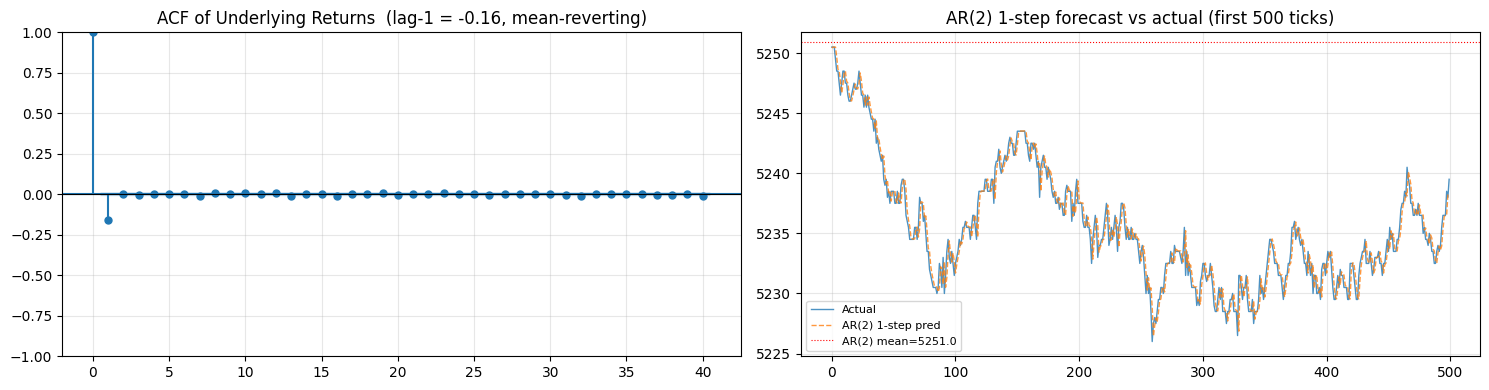

In [15]:
# ── Finding 3: AR(2) mean reversion in underlying ────────────────────────────
mid = und['mid'].values
ret = np.diff(mid)

# Fit AR(2): mid[t] = c + b1*mid[t-1] + b2*mid[t-2]
Y  = mid[2:]
X  = np.column_stack([np.ones(len(Y)), mid[1:-1], mid[:-2]])
b, *_ = np.linalg.lstsq(X, Y, rcond=None)
alpha_ar, b1, b2 = b
ar2_mean = alpha_ar / (1 - b1 - b2)

print(f"AR(2): c={alpha_ar:.4f}  b1={b1:.6f}  b2={b2:.6f}")
print(f"Long-run mean = c/(1-b1-b2) = {ar2_mean:.2f}")
print(f"Return autocorr lag-1: {pd.Series(ret).autocorr(1):.4f}")
print(f"Return autocorr lag-2: {pd.Series(ret).autocorr(2):.4f}")

# 1-step AR(2) prediction
pred   = alpha_ar + b1 * mid[1:-1] + b2 * mid[:-2]
errors = mid[2:] - pred
print(f"AR(2) 1-step RMSE: {np.sqrt(np.mean(errors**2)):.4f}")
print(f"Naive (no-change) RMSE: {np.sqrt(np.mean(ret**2)):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# ACF of returns
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(ret, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Underlying Returns  (lag-1 = -0.16, mean-reverting)')
axes[0].axhline(0, color='black', lw=0.8)

# AR(2) prediction vs actual (short window)
window = slice(0, 500)
axes[1].plot(mid[2:][window], lw=1, label='Actual', alpha=0.8)
axes[1].plot(pred[window], lw=1, ls='--', label='AR(2) 1-step pred', alpha=0.8)
axes[1].axhline(ar2_mean, color='red', lw=0.8, ls=':', label=f'AR(2) mean={ar2_mean:.1f}')
axes[1].set_title('AR(2) 1-step forecast vs actual (first 500 ticks)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

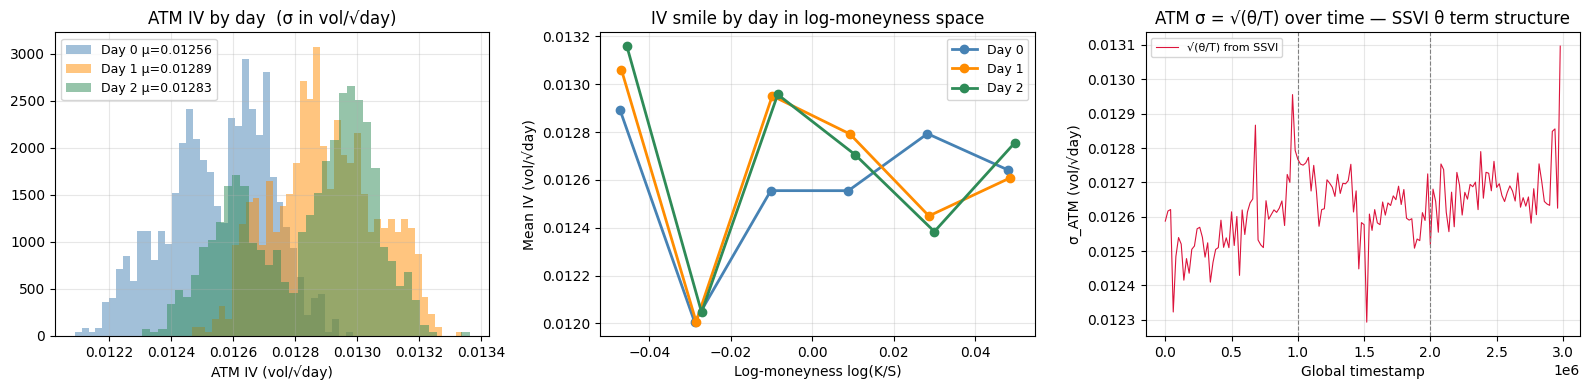

TTE at round 0 start: 80,000 ticks  (8 days)
TTE at round 1 start: 70,000 ticks  (7 days)
TTE at round 2 start: 60,000 ticks  (6 days)
TTE at round 3 start: 50,000 ticks  (5 days)  ← current


In [16]:
# ── Finding 4: ATM IV declining across days (vol term structure) ──────────────
und_lookup = und.set_index(['day','timestamp'])['mid']
smile_rows = []
for sym, K in zip(OPT_SYMS, STRIKES):
    if K not in SSVI_STRIKES:
        continue
    df_o = opts[sym][['day','timestamp','global_ts']].copy()
    df_o['price'] = make_opt_mid(opts[sym]).values
    df_o['S']     = df_o.apply(lambda r: und_lookup.get((r['day'], r['timestamp']), np.nan), axis=1)
    df_o = df_o.iloc[::10].copy()
    df_o['T']     = df_o['global_ts'].apply(tte_at)
    df_o['iv']    = df_o.apply(lambda r: implied_vol(r['price'], r['S'], K, r['T']), axis=1)
    df_o['K']     = K
    df_o['log_m'] = np.log(df_o['S'] / K)
    smile_rows.append(df_o.dropna(subset=['iv']))

smile_df = pd.concat(smile_rows, ignore_index=True)

smile_df['abs_lm'] = smile_df['log_m'].abs()
atm_iv = (smile_df.sort_values('abs_lm')
                  .groupby(['day','timestamp'])['iv'].first()
                  .reset_index())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors_d = ['steelblue','darkorange','seagreen']

for day, c in zip([0,1,2], colors_d):
    v = atm_iv[atm_iv['day']==day]['iv'].dropna() * np.sqrt(TICKS_PER_DAY)
    axes[0].hist(v, bins=40, alpha=0.5, color=c,
                 label=f'Day {day} μ={v.mean():.5f}', density=True)
axes[0].set_title('ATM IV by day  (σ in vol/√day)')
axes[0].set_xlabel('ATM IV (vol/√day)'); axes[0].legend(fontsize=9)

for day, c in zip([0,1,2], colors_d):
    d = smile_df[smile_df['day']==day]
    iv_by_k = d.groupby('K')['iv'].mean() * np.sqrt(TICKS_PER_DAY)
    ks = np.log(d.groupby('K')['S'].mean() / d.groupby('K')['K'].mean())
    axes[1].plot(ks, iv_by_k.values, 'o-', color=c, label=f'Day {day}', lw=2)
axes[1].set_title('IV smile by day in log-moneyness space')
axes[1].set_xlabel('Log-moneyness log(K/S)'); axes[1].set_ylabel('Mean IV (vol/√day)')
axes[1].legend(fontsize=9)

# ATM IV from SSVI theta: σ_ATM = sqrt(theta / T)
if df_ssvi['theta'].notna().any():
    atm_iv_ts = np.sqrt(df_ssvi['theta'] / df_ssvi['T_days'])
    axes[2].plot(atm_iv_ts.index, atm_iv_ts.values, lw=0.8, color='crimson',
                 label='√(θ/T) from SSVI')
    for d in [1,2]:
        axes[2].axvline(d*1_000_000, color='grey', lw=0.8, ls='--')
    axes[2].set_title('ATM σ = √(θ/T) over time — SSVI θ term structure')
    axes[2].set_xlabel('Global timestamp'); axes[2].set_ylabel('σ_ATM (vol/√day)')
    axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

print(f"TTE at round 0 start: {tte_at(0):,.0f} ticks  ({tte_at(0)/TICKS_PER_DAY:.0f} days)")
print(f"TTE at round 1 start: {tte_at(1_000_000):,.0f} ticks  ({tte_at(1_000_000)/TICKS_PER_DAY:.0f} days)")
print(f"TTE at round 2 start: {tte_at(2_000_000):,.0f} ticks  ({tte_at(2_000_000)/TICKS_PER_DAY:.0f} days)")
print(f"TTE at round 3 start: {tte_at(3_000_000):,.0f} ticks  ({tte_at(3_000_000)/TICKS_PER_DAY:.0f} days)  ← current")

ADF test on price_dev (p<0.05 -> stationary, exploitable):
  VEV_5000: ADF p=2.62e-03  STATIONARY  AR(1) phi=0.2713  half-life~1 ticks
  VEV_5100: ADF p=2.70e-01    AR(1) phi=0.8271  half-life~4 ticks
  VEV_5200: ADF p=1.48e-01    AR(1) phi=0.8818  half-life~6 ticks
  VEV_5300: ADF p=5.90e-01    AR(1) phi=0.9578  half-life~16 ticks
  VEV_5400: ADF p=8.96e-02    AR(1) phi=0.9521  half-life~14 ticks
  VEV_5500: ADF p=1.20e-02  STATIONARY  AR(1) phi=0.8181  half-life~3 ticks


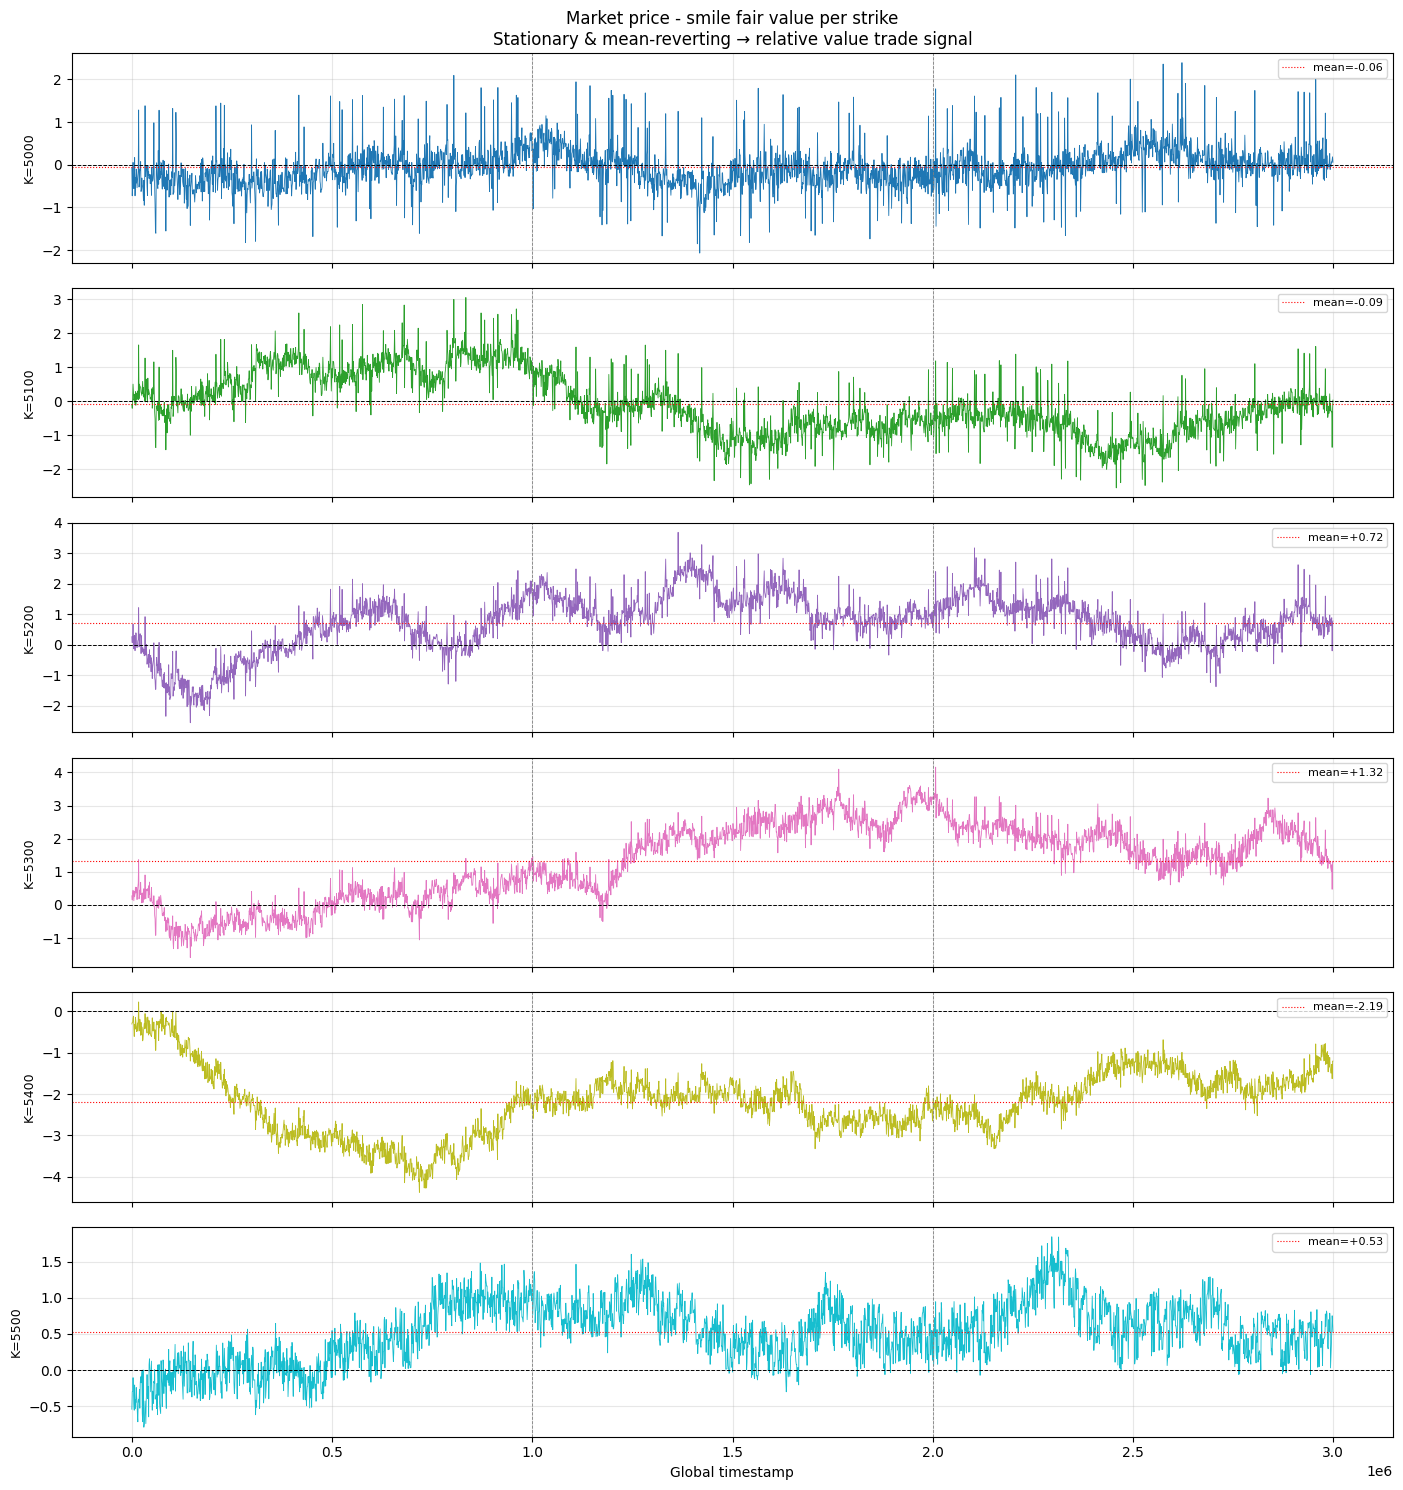

In [18]:
# ── Finding 5: IV smile residuals are stationary + mean-reverting ─────────────
# Global parabola in log-moneyness space
lm_  = smile_df['log_m'].values
iv__ = smile_df['iv'].values
coeffs_global = np.polyfit(lm_, iv__, 2)
SABR_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

smile_df['iv_fit']    = np.polyval(coeffs_global, smile_df['log_m'])
# Use per-row T (time-varying TTE in ticks) for accurate fair-price computation
smile_df['fair_px']   = smile_df.apply(
    lambda r: bs_call(r['S'], r['K'], r['T'], r['iv_fit']), axis=1)
smile_df['price_dev'] = smile_df['price'] - smile_df['fair_px']

print("ADF test on price_dev (p<0.05 -> stationary, exploitable):")
for K in SABR_STRIKES:
    s   = smile_df[smile_df['K']==K].sort_values('global_ts')['price_dev'].dropna().values
    p   = adfuller(s, autolag='AIC')[1]
    phi = np.polyfit(s[:-1], s[1:], 1)[0]
    hl  = -np.log(2)/np.log(phi) if 0 < phi < 1 else float('nan')
    stat = 'STATIONARY' if p < 0.05 else ''
    print(f"  VEV_{K}: ADF p={p:.2e}  {stat}  AR(1) phi={phi:.4f}  half-life~{hl:.0f} ticks")

fig, axes = plt.subplots(len(SABR_STRIKES), 1, figsize=(14, 2.5*len(SABR_STRIKES)), sharex=True)
colors_k = cm.tab10(np.linspace(0, 1, len(SABR_STRIKES)))
for ax, K, c in zip(axes, SABR_STRIKES, colors_k):
    s = smile_df[smile_df['K']==K].sort_values('global_ts')
    ax.plot(s['global_ts'], s['price_dev'], lw=0.6, color=c)
    ax.axhline(0, color='black', lw=0.7, ls='--')
    mean_dev = s['price_dev'].mean()
    ax.axhline(mean_dev, color='red', lw=0.8, ls=':', label=f'mean={mean_dev:+.2f}')
    for d in [1, 2]:
        ax.axvline(d * 1_000_000, color='grey', lw=0.6, ls='--')
    ax.set_ylabel(f'K={K}', fontsize=9)
    ax.legend(fontsize=8, loc='upper right')
axes[0].set_title('Market price - smile fair value per strike\n'
                  'Stationary & mean-reverting → relative value trade signal')
axes[-1].set_xlabel('Global timestamp')
plt.tight_layout()
plt.show()